# Avaliação dos Modelos de Fatoração de Matrizes

Objetivo: Implementar e avaliar os modelo ALS

### Importando as bibliotecas

In [1]:
import numpy as np
import pandas as pd
from scipy.sparse import csr_matrix
import sys
import os
sys.path.append(os.path.abspath("../src"))
from data_processing import load_and_prepare_data, split_train_validation, create_mappings
from evaluation import evaluate_recommender

### Carregando e preparando os dados

In [2]:
df = load_and_prepare_data("../data/processed/online_retail_clean.parquet")
train_df, validation_df = split_train_validation(df)

## remove cold users e cold items (<5 interações) da base de treino
train_user_counts = train_df['CustomerID'].value_counts()
cold_users = train_user_counts[train_user_counts < 5].index
train_item_counts = train_df['StockCode'].value_counts()
cold_items = train_item_counts[train_item_counts < 5].index
train_df = train_df[~train_df['StockCode'].isin(cold_items)]
train_df = train_df[~train_df['CustomerID'].isin(cold_users)]

# Criando os mapeamentos de IDs para índices
user_map, item_map, inverse_user_map, inverse_item_map = create_mappings(train_df)

In [3]:
train_user_items = (train_df.drop_duplicates(['CustomerID','InvoiceNo','StockCode'])
                    .groupby('CustomerID')['StockCode'].apply(set).to_dict())

validation_user_items = (validation_df.drop_duplicates(['CustomerID','InvoiceNo','StockCode'])
                         .groupby('CustomerID')['StockCode'].apply(set).to_dict())

validation_users = list(validation_user_items.keys())
valid_users_for_eval = [u for u in validation_users if u in user_map]

In [4]:
from als_utils import (
    build_interaction_matrix,
    apply_bm25_or_tfidf,
    train_als,
    recommend_user,
)


In [5]:
# 1) Construir matriz com confiança log e ALPHA=40
user_item_csr = build_interaction_matrix(
    train_df, user_map, item_map, weight="count", alpha=40.0
)
print("Matriz (users x items):", user_item_csr.shape, 'nnz=', user_item_csr.nnz)

# 2) Opcional: aplicar BM25/TF-IDF (em item-user)
WEIGHTING_METHOD = None  # 'bm25', 'tfidf' ou None
user_item_csr = apply_bm25_or_tfidf(user_item_csr, method=WEIGHTING_METHOD)
print("Após weighting:", user_item_csr.shape, 'nnz=', user_item_csr.nnz)


Matriz (users x items): (2703, 3049) nnz= 193832
Após weighting: (2703, 3049) nnz= 193832


In [6]:
# 3) Treinar ALS (fit espera item-user; utilitário já transpõe)
model_als2 = train_als(
    user_item_csr, factors=64, regularization=0.01, iterations=20, use_gpu=False, random_state=42
)


c:\Users\DiegoGonçalvesMota\Documents\tcc\recommender-system\venv\Lib\site-packages\implicit\cpu\als.py:95: RuntimeWarning: OpenBLAS is configured to use 8 threads. It is highly recommended to disable its internal threadpool by setting the environment variable 'OPENBLAS_NUM_THREADS=1' or by calling 'threadpoolctl.threadpool_limits(1, "blas")'. Having OpenBLAS use a threadpool can lead to severe performance issues here.
  check_blas_config()


  0%|          | 0/20 [00:00<?, ?it/s]

In [7]:
# 4) Função de recomendação
def recommend_als_items2(user_id, K, exclude):
    return recommend_user(
        model_als2, 
        user_id, 
        user_map, 
        inverse_item_map, 
        user_item_csr, 
        K=K, 
        filter_history=False, # Desliga o filtro automático do histórico
        exclude=exclude       # Passa o exclude manual (que pode vir vazio ou não)
    )


In [8]:
# 5) Avaliar em K={5,10,20} usando o framework existente
K_values = [5, 10, 20]
all_results_als2 = []
empty_exclude_dict = {} 
for k in K_values:
    res = evaluate_recommender(
        users=valid_users_for_eval,
        recommend_fn=recommend_als_items2,
        truth_dict=validation_user_items,
        exclude_seen_dict=empty_exclude_dict,
        k=k,
    )
    row = {
        'K': k,
        'users_eval': res['users_eval'],
        'Precision': res[f'P@{k}'],
        'Recall': res[f'R@{k}'],
        'NDCG': res[f'NDCG@{k}'],
    }
    all_results_als2.append(row)

results_df_als2 = pd.DataFrame(all_results_als2).set_index('K')
print("Resultados ALS (utils)")
print(results_df_als2)


Resultados ALS (utils)
    users_eval  Precision    Recall      NDCG
K                                            
5         2703   0.209101  0.090733  0.232736
10        2703   0.175620  0.140387  0.220923
20        2703   0.142823  0.207495  0.223691


--- Estatísticas de Atividade dos Usuários ---
count    2703.000000
mean      110.167592
std       265.132646
min         4.000000
25%        23.000000
50%        54.000000
75%       116.000000
max      7515.000000
Name: StockCode, dtype: float64

--- Top 5 Usuários com mais transações ---
CustomerID
17841    7515
14911    5453
14096    4545
12748    4331
14606    2601
Name: StockCode, dtype: int64


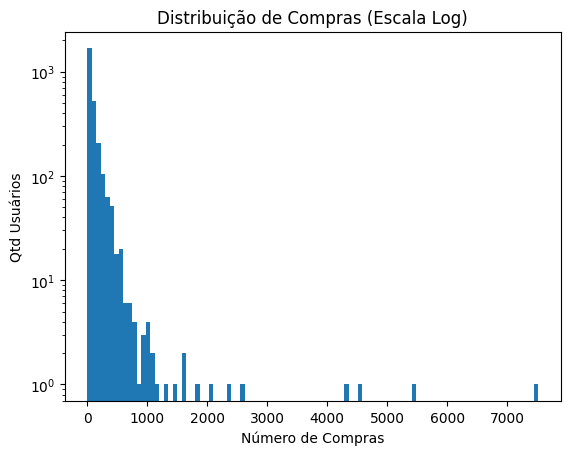

In [9]:
# Analisando a distribuição de compras por usuário
user_activity = train_df.groupby('CustomerID')['StockCode'].count()
print("--- Estatísticas de Atividade dos Usuários ---")
print(user_activity.describe())

# Ver quem são os "monstros" (Top 5)
print("\n--- Top 5 Usuários com mais transações ---")
print(user_activity.sort_values(ascending=False).head(5))

# Plotar histograma rápido (se tiver matplotlib)
import matplotlib.pyplot as plt
plt.hist(user_activity, bins=100, range=(1, user_activity.max()), log=True)
plt.title("Distribuição de Compras (Escala Log)")
plt.xlabel("Número de Compras")
plt.ylabel("Qtd Usuários")
plt.show()

### Tuning rápido de hiperparâmetros (seleção por NDCG@10)

In [10]:
from copy import deepcopy
import itertools

param_grid = {
    'factors': [32, 50, 100],
    'reg': [0.01, 0.1, 0.5],
    'iters': [20, 30, 100],
    'weight': ['log', 'count', 'capped_count'], 
    'wmethod': [None, 'bm25', 'tfidf'],
}

keys, values = zip(*param_grid.items())
grids = [dict(zip(keys, v)) for v in itertools.product(*values)]

def evaluate_config(cfg):
    csr = build_interaction_matrix(train_df, user_map, item_map, weight=cfg['weight'], alpha=40.0)
    csr = apply_bm25_or_tfidf(csr, method=cfg['wmethod'], bm25_K1=100.0, bm25_B=0.8)
    if cfg['wmethod'] == 'bm25':
        csr = csr * 20.0
    model = train_als(csr, factors=cfg['factors'], regularization=cfg['reg'], iterations=cfg['iters'], use_gpu=False, random_state=42)
    rec_fn = lambda u, K, exclude: recommend_user(model, u, user_map, inverse_item_map, csr, K=K, exclude={}, filter_history=False)
    res10 = evaluate_recommender(valid_users_for_eval, rec_fn, validation_user_items, train_user_items, k=10)
    return res10, rec_fn, csr, model

summary = []
artifacts = []
for cfg in grids:
    res10, rec_fn, csr_cfg, model_cfg = evaluate_config(cfg)
    summary.append({
        'factors': cfg['factors'], 'reg': cfg['reg'], 'iters': cfg['iters'], 'weight': cfg['weight'], 'wmethod': cfg['wmethod'],
        'users_eval': res10['users_eval'], 'P@10': res10['P@10'], 'R@10': res10['R@10'], 'NDCG@10': res10['NDCG@10']
    })
    artifacts.append((deepcopy(cfg), rec_fn, csr_cfg, model_cfg))

df_summary = pd.DataFrame(summary).sort_values('NDCG@10', ascending=False).reset_index(drop=True)
print(df_summary)

best_cfg_dict = df_summary.iloc[0].to_dict()
print('Melhor configuração encontrada:', {k: best_cfg_dict[k] for k in grids[0].keys()})

original_index = grids.index({k: best_cfg_dict[k] for k in grids[0].keys()})
best_cfg, best_rec_fn, best_csr, best_model = artifacts[original_index]

# Avaliar melhor em K={5,10,20}
best_rows = []
for k in [5, 10, 20]:
    resk = evaluate_recommender(valid_users_for_eval, best_rec_fn, validation_user_items, train_user_items, k=k)
    best_rows.append({
        'K': k, 'users_eval': resk['users_eval'], 'Precision': resk[f'P@{k}'], 'Recall': resk[f'R@{k}'], 'NDCG': resk[f'NDCG@{k}']
    })
best_table = pd.DataFrame(best_rows).set_index('K')
print('Resultados (melhor cfg):')
print(best_table)


  0%|          | 0/20 [00:00<?, ?it/s]

  0%|          | 0/20 [00:00<?, ?it/s]

  0%|          | 0/20 [00:00<?, ?it/s]

  0%|          | 0/20 [00:00<?, ?it/s]

  0%|          | 0/20 [00:00<?, ?it/s]

...

  0%|          | 0/100 [00:00<?, ?it/s]

  0%|          | 0/100 [00:00<?, ?it/s]

  0%|          | 0/100 [00:00<?, ?it/s]

  0%|          | 0/100 [00:00<?, ?it/s]

     factors   reg  iters        weight wmethod  users_eval      P@10  \
0        100  0.10    100         count    None        2703  0.177617   
1        100  0.01     20  capped_count    None        2703  0.177211   
2        100  0.10    100  capped_count    None        2703  0.177691   
3        100  0.01     20         count    None        2703  0.177100   
4        100  0.50     30         count    None        2703  0.177654   
..       ...   ...    ...           ...     ...         ...       ...   
238       32  0.50     20           log    bm25        2703  0.027414   
239       32  0.01     30           log    bm25        2703  0.026119   
240       32  0.10     30           log    bm25        2703  0.025712   
241       32  0.10     20           log    bm25        2703  0.024306   
242       32  0.01     20           log    bm25        2703  0.024010   

         R@10   NDCG@10  
0    0.144088  0.221256  
1    0.143132  0.221211  
2    0.143984  0.221202  
3    0.143101  0.22

In [11]:
pd.set_option('display.max_rows', None)

pd.set_option('display.max_columns', None)

pd.set_option('display.width', 1000)

print(df_summary)

     factors   reg  iters        weight wmethod  users_eval      P@10      R@10   NDCG@10
0        100  0.10    100         count    None        2703  0.177617  0.144088  0.221256
1        100  0.01     20  capped_count    None        2703  0.177211  0.143132  0.221211
2        100  0.10    100  capped_count    None        2703  0.177691  0.143984  0.221202
3        100  0.01     20         count    None        2703  0.177100  0.143101  0.221173
4        100  0.50     30         count    None        2703  0.177654  0.143979  0.221169
5        100  0.50     30  capped_count    None        2703  0.177691  0.143855  0.221145
6        100  0.50    100  capped_count    None        2703  0.177728  0.144229  0.221005
7        100  0.50    100         count    None        2703  0.177765  0.144156  0.220958
8        100  0.10     20  capped_count    None        2703  0.177100  0.142930  0.220909
9        100  0.10     20         count    None        2703  0.177063  0.142854  0.220868
10       1

In [12]:
def get_results_df(results, model_name):
    """
    Converte a lista de resultados em um DataFrame e adiciona o nome do modelo.
    """
    df_results = pd.DataFrame(results)
    df_results['Model'] = model_name
    return df_results

def compare_models(df_model_A, df_model_B, model_A_name, model_B_name, metric_cols=['Precision', 'Recall', 'NDCG']):
    """
    Compara as métricas de dois modelos e imprime o resultado formatado
    com a melhoria percentual.
    """
    print(f"--- Comparação: {model_A_name} vs. {model_B_name} ---\n")
    
    # Junta os dois dataframes pela coluna 'K'
    comparison_df = pd.merge(df_model_A, df_model_B, on='K', suffixes=(f'_{model_A_name}', f'_{model_B_name}'))
    
    for k_value in comparison_df['K'].unique():
        print(f"K={k_value}\n")
        
        row = comparison_df[comparison_df['K'] == k_value].iloc[0]
        
        for metric in metric_cols:
            val_A = row[f'{metric}_{model_A_name}']
            val_B = row[f'{metric}_{model_B_name}']
            
            # Calcula a melhoria percentual (uplift)
            uplift = ((val_A - val_B) / val_B) * 100 if val_B > 0 else float('inf')
            
            # Formata a string de saída
            print(f"- {metric}@{k_value}: {val_A:.4f} vs {val_B:.4f} → {uplift:+.0f}%")
        
        print("-" * 20)

df_knn = pd.read_parquet("../data/processed/df_knn.parquet")
df_als = get_results_df(best_rows, "ALS")

compare_models(df_als, df_knn, "ALS", "KNN")

--- Comparação: ALS vs. KNN ---

K=5

- Precision@5: 0.2062 vs 0.1361 → +52%
- Recall@5: 0.0918 vs 0.0610 → +51%
- NDCG@5: 0.2287 vs 0.1502 → +52%
--------------------
K=10

- Precision@10: 0.1776 vs 0.1166 → +52%
- Recall@10: 0.1441 vs 0.0953 → +51%
- NDCG@10: 0.2213 vs 0.1453 → +52%
--------------------
K=20

- Precision@20: 0.1468 vs 0.0925 → +59%
- Recall@20: 0.2167 vs 0.1374 → +58%
- NDCG@20: 0.2275 vs 0.1460 → +56%
--------------------


In [13]:
item_descriptions = train_df[['StockCode', 'Description']].drop_duplicates('StockCode').set_index('StockCode')['Description'].to_dict()

def print_user_history_and_recs(user_id, rec_function, item_desc_map, k=5):
    print(f"==================================================")
    print(f"👤 ANÁLISE DO USUÁRIO: {user_id}")
    print(f"==================================================")
    
    # A. Histórico de Compras (O que ele já comprou)
    # Filtramos o dataframe original para este usuário e removemos duplicatas para mostrar apenas os itens únicos
    user_history = train_df[train_df['CustomerID'] == user_id][['StockCode', 'Description']].drop_duplicates().head(10)
    
    print(f"\n🛍️  ÚLTIMAS 10 COMPRAS (Histórico):")
    print(f"{'StockCode':<15} | {'Descrição'}")
    print("-" * 60)
    for _, row in user_history.iterrows():
        # Trunca a descrição se for muito longa para caber na tela
        desc = str(row['Description'])[:40] 
        print(f"{row['StockCode']:<15} | {desc}")
        
    # B. Recomendações (O que o modelo sugere)
    print(f"\n✨ TOP {k} RECOMENDAÇÕES DO MODELO:")
    print(f"{'StockCode':<15} | {'Descrição'}")
    print("-" * 60)
    
    # Gera recomendações
    recs = rec_function(user_id, K=k, exclude=[])
    
    for stock_code in recs:
        # Busca a descrição no dicionário que criamos. Se não achar, avisa.
        desc = item_desc_map.get(stock_code, "Descrição não encontrada")
        desc = str(desc)[:40]
        print(f"{stock_code:<15} | {desc}")
    print("\n")

# --- EXECUÇÃO ---

# Escolha um usuário interessante (pode trocar o índice [0] por [10], [20] para ver outros)
example_user_id = valid_users_for_eval[1] 

# Chama a função usando seu 'best_rec_fn' que saiu do tuning
print_user_history_and_recs(example_user_id, best_rec_fn, item_descriptions, k=10)

👤 ANÁLISE DO USUÁRIO: 12348

🛍️  ÚLTIMAS 10 COMPRAS (Histórico):
StockCode       | Descrição
------------------------------------------------------------
84992           | 72 SWEETHEART FAIRY CAKE CASES
22951           | 60 CAKE CASES DOLLY GIRL DESIGN
84991           | 60 TEATIME FAIRY CAKE CASES
21213           | PACK OF 72 SKULL CAKE CASES
22616           | PACK OF 12 LONDON TISSUES
21981           | PACK OF 12 WOODLAND TISSUES
21982           | PACK OF 12 SUKI TISSUES
21725           | SWEETIES  STICKERS
21211           | SET OF 72 SKULL PAPER  DOILIES
84988           | SET OF 72 PINK HEART PAPER DOILIES

✨ TOP 10 RECOMENDAÇÕES DO MODELO:
StockCode       | Descrição
------------------------------------------------------------
21977           | PACK OF 60 PINK PAISLEY CAKE CASES
84991           | 60 TEATIME FAIRY CAKE CASES
21212           | PACK OF 72 RETROSPOT CAKE CASES
84992           | 72 SWEETHEART FAIRY CAKE CASES
21975           | PACK OF 60 DINOSAUR CAKE CASES
21213        

# Preparando o modelo para o blending

In [14]:
import joblib

model_filename = '../data/raw/best_als_model.joblib'
joblib.dump(best_model, model_filename)

['../data/raw/best_als_model.joblib']

In [15]:
try:
    # Tenta salvar os mapas usados no create_mappings
    mappings = {
        'user_map': user_map, 
        'item_map': item_map,
        'inverse_item_map': inverse_item_map # Útil para traduzir de volta
    }
    mappings_path = '../models/als_mappings.joblib'
    joblib.dump(mappings, mappings_path)
    print(f"✅ Mapeamentos salvos em: {mappings_path}")
    
except NameError:
    print("⚠️ AVISO: Variáveis 'user_map' ou 'item_map' não encontradas.")
    print("Certifique-se de que elas estão definidas na célula onde você carregou os dados.")
    print("Geralmente: user_map, item_map, _, inverse_item_map = create_mappings(train_df)")

print("\nExportação concluída! Agora o notebook de Blending pode carregar o modelo E os mapas corretos.")

✅ Mapeamentos salvos em: ../models/als_mappings.joblib

Exportação concluída! Agora o notebook de Blending pode carregar o modelo E os mapas corretos.
